In [ ]:
# RESEARCH QUESTION: What are the five closest museums to my commute from Astoria to Columbia University (In this case only considering stops between midtown 42st station and Columbia)?
# Nodes, 1. My subway Stops, 2. Museums, 3. Streets

In [107]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString, MultiLineString, Point, Polygon
import pandas as pd
import requests
import networkx as nx
import osmnx as ox
import h3
import libpysal as lps

In [108]:
from cdptools import utils

In [109]:
utils.set_axis_off()

In [110]:
# bounding box of nyc
bbox = (-74.3, 40.5, -73.7, 40.9)

In [111]:
requests.get("https://data.ny.gov/api/v3/views/39hk-dx4f/query.json?accessType=API")

<Response [200]>

In [112]:
subway_stations = requests.get(
    "https://data.ny.gov/api/v3/views/39hk-dx4f/query.json?accessType=API"
).json()

In [113]:
# Get Stops on my Commute

# N line: Broadway (Astoria) -> Times Sq-42 St
n_line_ids = ["R11", "R13", "R14", "R15", "R16"]

# 1 train: Times Sq-42 St -> 116 St-Columbia University
one_line_ids = [
    "127",
    "126",
    "125",
    "124",
    "123",
    "122",
    "121",
    "120",
    "119",
    "118",
    "117",
]

corridor_ids = n_line_ids + one_line_ids

# keep only the records on these two segments (still plain dicts at this point)
records = [s for s in subway_stations if str(s["gtfs_stop_id"]).strip() in corridor_ids]

# build the geodataframe from just those stops
my_subway_stops = gpd.GeoDataFrame(
    records,
    geometry=gpd.points_from_xy(
        [r["georeference"]["coordinates"][0] for r in records],
        [r["georeference"]["coordinates"][1] for r in records],
    ),
    crs="EPSG:4326",
)

my_subway_stops.fillna("na", inplace=True)

# label route and sort in travel order
my_subway_stops["route"] = my_subway_stops["gtfs_stop_id"].apply(
    lambda s: "N (Astoria-Times Sq)" if s in n_line_ids else "1 (Times Sq-116 St)"
)
my_subway_stops["stop_order"] = my_subway_stops["gtfs_stop_id"].apply(
    corridor_ids.index
)
my_subway_stops = my_subway_stops.sort_values("stop_order").reset_index(drop=True)

print(f"matched {len(my_subway_stops)} of {len(corridor_ids)} stops")
my_subway_stops[
    ["gtfs_stop_id", "stop_name", "line", "daytime_routes", "borough", "route"]
]

matched 16 of 16 stops


,gtfs_stop_id,stop_name,line,daytime_routes,borough,route
0,R11,Lexington Av/59 St,Astoria,N R W,M,N (Astoria-Times Sq)
1,R13,5 Av/59 St,Astoria,N R W,M,N (Astoria-Times Sq)
2,R14,57 St-7 Av,Broadway - Brighton,N Q R W,M,N (Astoria-Times Sq)
3,R15,49 St,Broadway - Brighton,N R W,M,N (Astoria-Times Sq)
4,R16,Times Sq-42 St,Broadway - Brighton,N Q R W,M,N (Astoria-Times Sq)
5,127,Times Sq-42 St,Broadway - 7Av,1 2 3,M,1 (Times Sq-116 St)
6,126,50 St,Broadway - 7Av,1,M,1 (Times Sq-116 St)
7,125,59 St-Columbus Circle,Broadway - 7Av,1,M,1 (Times Sq-116 St)
8,124,66 St-Lincoln Center,Broadway - 7Av,1,M,1 (Times Sq-116 St)
9,123,72 St,Broadway - 7Av,1 2 3,M,1 (Times Sq-116 St)


In [114]:
my_subway_stops.fillna("na", inplace=True)

,:id,:version,:created_at,:updated_at,gtfs_stop_id,station_id,complex_id,division,line,stop_name,...,ada_northbound,ada_southbound,georeference,:@computed_region_yamh_8v7k,:@computed_region_wbg7_3whc,:@computed_region_kjdx_g34t,ada_notes,geometry,route,stop_order
0,row-9jnx.5dj4~wrrs,rv-rqp9.icfn_dg7v,2026-08-07T04:19:06.972Z,2026-08-07T04:19:11.592Z,R11,7,613,BMT,Astoria,Lexington Av/59 St,...,0,0,"{'type': 'Point', 'coordinates': [-73.967258, ...",749,749,2095,na,POINT (-73.96726 40.76266),N (Astoria-Times Sq),0
1,row-7cwb.at9y.jdpf,rv-7egj.ewwz_wi3p,2026-08-07T04:19:06.972Z,2026-08-07T04:19:11.592Z,R13,8,8,BMT,Astoria,5 Av/59 St,...,0,0,"{'type': 'Point', 'coordinates': [-73.973347, ...",749,na,2095,na,POINT (-73.97335 40.76481),N (Astoria-Times Sq),1
2,row-scmf_rpam.nye6,rv-z5qx.bm4b_7gue,2026-08-07T04:19:06.972Z,2026-08-07T04:19:11.592Z,R14,9,9,BMT,Broadway - Brighton,57 St-7 Av,...,1,1,"{'type': 'Point', 'coordinates': [-73.980658, ...",749,742,2095,na,POINT (-73.98066 40.76466),N (Astoria-Times Sq),2
3,row-pwqf.jizm~hy6h,rv-pejy.h94s_436u,2026-08-07T04:19:06.972Z,2026-08-07T04:19:11.592Z,R15,10,10,BMT,Broadway - Brighton,49 St,...,1,0,"{'type': 'Point', 'coordinates': [-73.984139, ...",749,742,2095,Uptown only,POINT (-73.98414 40.7599),N (Astoria-Times Sq),3
4,row-bnya.mrup.5qz8,rv-fzzr-us47-6an4,2026-08-07T04:19:06.972Z,2026-08-07T04:19:11.592Z,R16,11,611,BMT,Broadway - Brighton,Times Sq-42 St,...,1,1,"{'type': 'Point', 'coordinates': [-73.986754, ...",749,741,2095,na,POINT (-73.98675 40.75467),N (Astoria-Times Sq),4
5,row-pqw3-3cvf.nezv,rv-wu3s~wx4g_tb72,2026-08-07T04:19:06.972Z,2026-08-07T04:19:11.592Z,127,317,611,IRT,Broadway - 7Av,Times Sq-42 St,...,1,1,"{'type': 'Point', 'coordinates': [-73.987495, ...",749,741,2095,na,POINT (-73.9875 40.75529),1 (Times Sq-116 St),5
6,row-nd9w-z3ew-kty3,rv-96rv_7k8g.4esn,2026-08-07T04:19:06.972Z,2026-08-07T04:19:11.592Z,126,316,316,IRT,Broadway - 7Av,50 St,...,0,0,"{'type': 'Point', 'coordinates': [-73.983849, ...",749,742,2095,na,POINT (-73.98385 40.76173),1 (Times Sq-116 St),6
7,row-qtnm.k9nq.kddq,rv-nj2k~ewij~i2sa,2026-08-07T04:19:06.972Z,2026-08-07T04:19:11.592Z,125,315,614,IRT,Broadway - 7Av,59 St-Columbus Circle,...,1,1,"{'type': 'Point', 'coordinates': [-73.981929, ...",749,742,2095,na,POINT (-73.98193 40.76825),1 (Times Sq-116 St),7
8,row-sii4~r67d-shwa,rv-q9n9~c56p.wdvp,2026-08-07T04:19:06.972Z,2026-08-07T04:19:11.592Z,124,314,314,IRT,Broadway - 7Av,66 St-Lincoln Center,...,1,1,"{'type': 'Point', 'coordinates': [-73.982209, ...",749,750,2095,na,POINT (-73.98221 40.77344),1 (Times Sq-116 St),8
9,row-g4qb~cbdx-8zg9,rv-q9vj.3egi-egqu,2026-08-07T04:19:06.972Z,2026-08-07T04:19:11.592Z,123,313,313,IRT,Broadway - 7Av,72 St,...,1,1,"{'type': 'Point', 'coordinates': [-73.98197, 4...",749,750,2095,na,POINT (-73.98197 40.77845),1 (Times Sq-116 St),9


In [115]:
point_network = ox.graph_from_point(
    (my_subway_stops.iloc[0].geometry.y, my_subway_stops.iloc[0].geometry.x),
    dist=6000,
    network_type="walk",
)

In [116]:
point_network

In [117]:
net_nodes, net_edges = ox.graph_to_gdfs(point_network)

<Axes: >

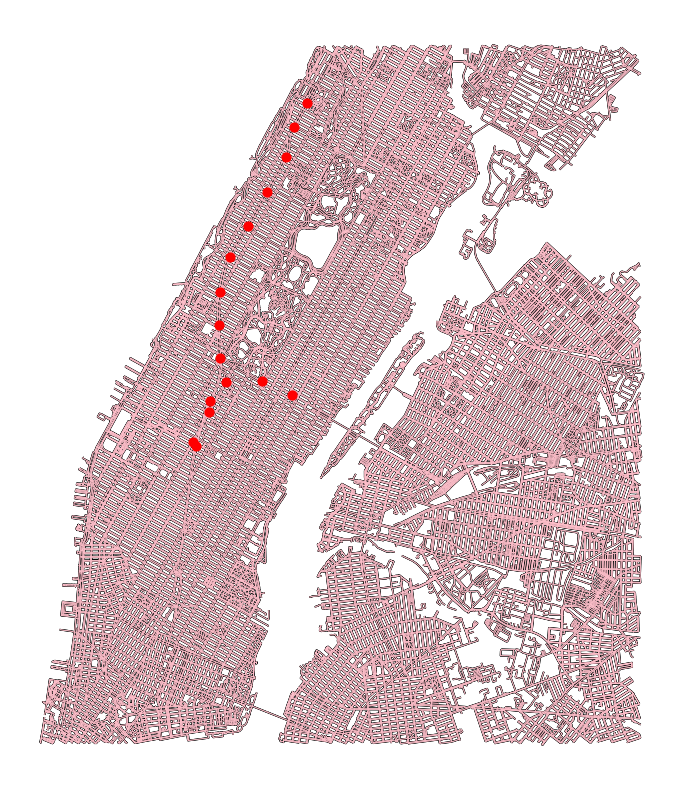

In [118]:
ax = net_edges.plot(color="black", linewidth=1.2, figsize=(10, 10), zorder=1)
net_edges.plot(ax=ax, color="pink", linewidth=0.5, zorder=2)
my_subway_stops.plot(ax=ax, color="red", markersize=40, zorder=3)

In [119]:
requests.get(
    "https://data.cityofnewyork.us/resource/fn6f-htvy.json",
    params={
        "$where": "zip in('10022','10023','10024','10025','10027')",
        "$limit": 2000,
    },
)

<Response [200]>

In [120]:
my_museums = requests.get(
    "https://data.cityofnewyork.us/resource/fn6f-htvy.json",
    params={
        "$where": "zip in('10022','10023','10024','10025','10027')",
        "$limit": 2000,
    },
).json()

In [121]:
pts = [x for x in my_museums if x.get("the_geom")]

my_museums = gpd.GeoDataFrame(
    pts,
    geometry=gpd.points_from_xy(
        [x["the_geom"]["coordinates"][0] for x in pts],
        [x["the_geom"]["coordinates"][1] for x in pts],
    ),
    crs="EPSG:4326",
)

<Axes: >

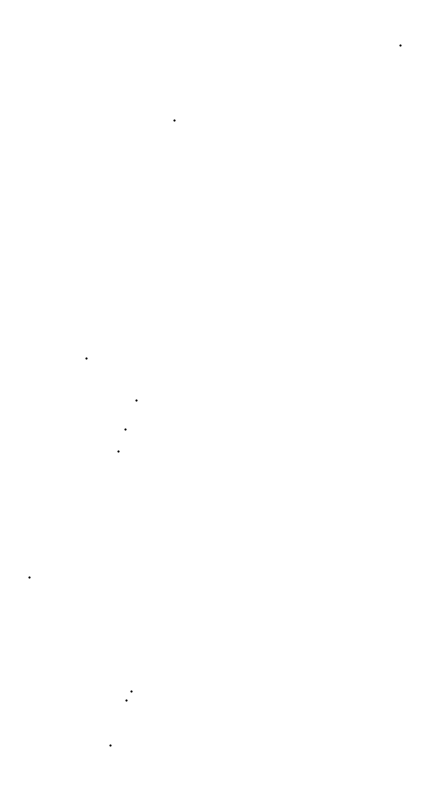

In [122]:
my_museums.plot(color="black", linewidth=0.1, markersize=2, figsize=(10, 10))

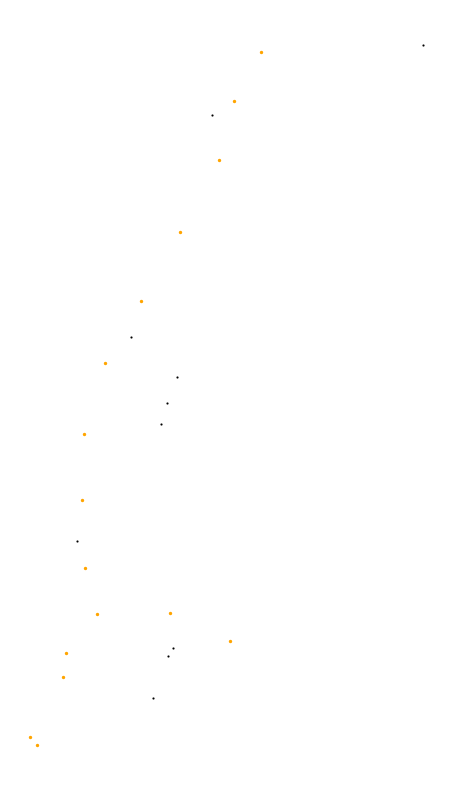

In [123]:
ax = my_museums.plot(color="black", linewidth=0.1, markersize=2, figsize=(10, 10))
my_subway_stops.plot(ax=ax, color="orange", markersize=2).set_axis_off()

In [125]:
# find three nearest museums for each subway stop
k = 3
neighbors = my_subway_stops.geometry.apply(
    lambda x: my_museums.geometry.distance(x)
).values.argsort(axis=1)[:, :k]

# join neighbors to original dataframe
my_subway_stops["neighbors"] = neighbors.tolist()

C:\Users\aqila\AppData\Local\Temp\ipykernel_39364\2474730643.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lambda x: my_museums.geometry.distance(x)


In [126]:
def create_lines(r):
    lines = []
    for i, neighbor in enumerate(r.neighbors):
        lines.append(LineString([r.geometry, my_museums.loc[neighbor].geometry]))
    return MultiLineString(lines)

In [127]:
my_subway_stops["line_geometry"] = my_subway_stops.apply(create_lines, axis=1)

In [128]:
lines_gdf = gpd.GeoDataFrame(
    my_subway_stops[["line_geometry"]], geometry="line_geometry", crs="EPSG:4326"
)

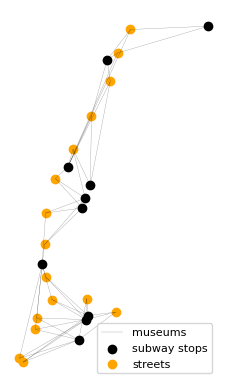

In [129]:
ax = lines_gdf.plot(color="black", alpha=0.5, linewidth=0.2)
my_museums.plot(ax=ax, color="black")
my_subway_stops.plot(ax=ax, color="orange")
ax.legend(["museums", "subway stops", "streets"], loc="lower right", fontsize=8)

In [130]:
# Network Distance
stops_p, museums_p = my_subway_stops.to_crs(2263), my_museums.to_crs(2263)

pd.DataFrame(
    [
        {
            "stop": my_subway_stops.loc[i, "stop_name"],
            "museum": my_museums.loc[n, "name"],
            "miles": round(
                stops_p.loc[i].geometry.distance(museums_p.loc[n].geometry) / 5280, 2
            ),
        }
        for i, r in my_subway_stops.iterrows()
        for n in r.neighbors
    ]
).sort_values("miles", ascending=False).reset_index(drop=True)

,stop,museum,miles
0,116 St-Columbia University,Children's Museum of Manhattan,1.66
1,Cathedral Pkwy (110 St),Children's Museum of Manhattan,1.36
2,103 St,Rose Center for Earth and Space (Hayden Planet...,1.17
3,Times Sq-42 St,Museum of Biblical Art,1.06
4,Cathedral Pkwy (110 St),Studio Museum in Harlem,1.05
5,103 St,Children's Museum of Manhattan,1.05
6,Times Sq-42 St,Dahesh Museum,0.88
7,116 St-Columbia University,Studio Museum in Harlem,0.86
8,Times Sq-42 St,Sony Wonder Technology Lab,0.85
9,Times Sq-42 St,Sony Wonder Technology Lab,0.84


In [131]:
# get euclidean distance between subway stops and museums

In [132]:
my_bbox = pd.concat([my_subway_stops, my_museums]).total_bounds
my_bbox

array([-73.987495  ,  40.754672  , -73.94772615,  40.80824548])

In [133]:
point_network = ox.graph_from_bbox(bbox=tuple(my_bbox), network_type="walk")
point_network

In [134]:
my_net_nodes, my_net_edges = ox.graph_to_gdfs(point_network)
my_net_edges.head()

osmid    highway  oneway reversed      length  \
u        v          key                                                      
30807314 2057103273 0     46613689  bridleway   False    False  159.255042   
         6579409036 0     46613689  bridleway   False     True   58.144181   
         4303265016 0    147089927    footway   False    False   10.509449   
         1203806304 0    147089927    footway   False     True   17.645411   
30978747 42442164   0    429504381       path   False    False   18.986534   

                                                                  geometry  \
u        v          key                                                      
30807314 2057103273 0    LINESTRING (-73.96358 40.79072, -73.9636 40.79...   
         6579409036 0    LINESTRING (-73.96358 40.79072, -73.96354 40.7...   
         4303265016 0    LINESTRING (-73.96358 40.79072, -73.96353 40.7...   
         1203806304 0    LINESTRING (-73.96358 40.79072, -73.96368 40.7...   
30978747 42442164   0    LINESTRING (-73.97342 40.77427, -73.97365 40.7...   

                                          name lanes maxspeed width bridge  \
u        v          key                                                      
30807314 2057103273 0                      NaN   NaN      NaN   NaN    NaN   
         6579409036 0                      NaN   NaN      NaN   NaN    NaN   
         4303265016 0                      NaN   NaN      NaN   NaN    NaN   
         1203806304 0                      NaN   NaN      NaN   NaN    NaN   
30978747 42442164   0    Central Park Driveway   NaN      NaN   NaN    NaN   

                        service tunnel access est_width junction area  
u        v          key                                                
30807314 2057103273 0       NaN    NaN    NaN       NaN      NaN  NaN  
         6579409036 0       NaN    NaN    NaN       NaN      NaN  NaN  
         4303265016 0       NaN    NaN    NaN       NaN      NaN  NaN  
         1203806304 0       NaN    NaN    NaN       NaN      NaN  NaN  
30978747 42442164   0       NaN    NaN    NaN       NaN      NaN  NaN

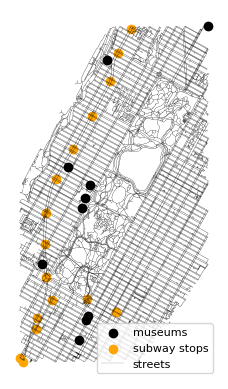

In [135]:
ax = my_museums.plot(color="black")
my_subway_stops.plot(ax=ax, color="orange")
my_net_edges.plot(ax=ax, color="black", linewidth=0.1)
ax.legend(["museums", "subway stops", "streets"], loc="lower right", fontsize=8)

                      stop                                             museum  \
0    59 St-Columbus Circle                             Museum of Biblical Art   
1  Cathedral Pkwy (110 St)                            Nicholas Roerich Museum   
2                    86 St                     Children's Museum of Manhattan   
3     66 St-Lincoln Center                             Museum of Biblical Art   
4                    79 St                     Children's Museum of Manhattan   
5               5 Av/59 St                                      Dahesh Museum   
6                   103 St                            Nicholas Roerich Museum   
7               5 Av/59 St                         Sony Wonder Technology Lab   
8       Lexington Av/59 St                                      Dahesh Museum   
9                    79 St  Rose Center for Earth and Space (Hayden Planet...   

   miles  
0   0.22  
1   0.23  
2   0.23  
3   0.25  
4   0.27  
5   0.29  
6   0.30  
7   0.32  
8   0.41 

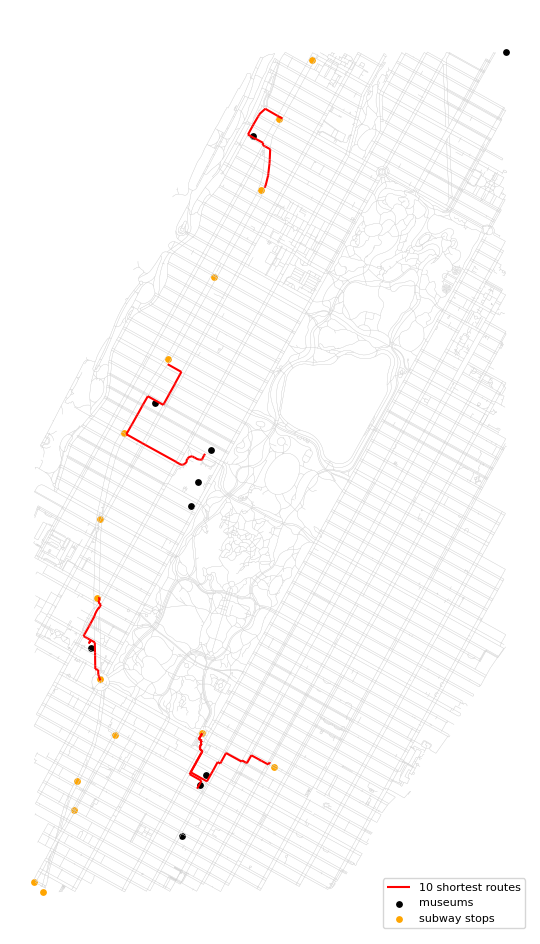

In [139]:
my_subway_stops = my_subway_stops.reset_index(drop=True)
my_museums = my_museums.reset_index(drop=True)

orig_nodes = ox.distance.nearest_nodes(
    point_network, my_subway_stops.geometry.x, my_subway_stops.geometry.y
)
dest_nodes = ox.distance.nearest_nodes(
    point_network, my_museums.geometry.x, my_museums.geometry.y
)

# find the shortest path between each stop and museum, minimizing distance
routes = []
for i, orig in enumerate(orig_nodes):
    for j, dest in enumerate(dest_nodes):
        route = ox.shortest_path(point_network, orig, dest, weight="length")
        if route is None or len(route) < 2:
            continue
        edge_lengths = ox.routing.route_to_gdf(point_network, route)["length"]
        routes.append(
            {
                "stop": my_subway_stops.loc[i, "stop_name"],
                "museum": my_museums.loc[j, "name"],
                "miles": sum(edge_lengths) / 1609.34,
                "route": route,
            }
        )

top10 = pd.DataFrame(routes).sort_values("miles").head(10).reset_index(drop=True)
print(top10[["stop", "museum", "miles"]].round(2))

routes_gdf = pd.concat(
    [ox.routing.route_to_gdf(point_network, r) for r in top10["route"]]
)
ax = my_net_edges.plot(color="lightgrey", linewidth=0.2, figsize=(12, 12))
routes_gdf.plot(ax=ax, color="red", linewidth=1.5, label="10 shortest routes")
my_museums.plot(ax=ax, color="black", markersize=15, label="museums")
my_subway_stops.plot(ax=ax, color="orange", markersize=15, label="subway stops")
ax.legend(loc="lower right", fontsize=8)

In [137]:
# Reflections: The five closest museums to my commute from Astoria to Columbia University are the Museum of the City of New York, The Jewish Museum, The Metropolitan Museum of Art, The Museum of Modern Art, and The American Museum of Natural History. These museums are all located within a few miles of my subway stops and can be easily accessed by walking or taking public transportation. From this data I also understand that the museums are typically more concentrated in certain areas of the city, some subway stops don't really have any museums near them. Though the network distance shows that a lot of museums are closeby to subways stops, the eucledian distance, which is the straight line distance, shows that some museums are actually farther away than they appear on the map.